In [12]:
import time
import joblib
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier

from features import (
load_image_mask_pair, 
build_training_table,
extract_features, 
FEATURE_NAMES,
)

from eval_utils import (
    predictions_to_mask,
    morphological_cleanup,
    evaluate,
    evaluate_dataset,
    print_metrics,
    save_mask,
)

In [ ]:
DATASET_ROOT = Path("../EWS_DATASET")
TRAIN_DIR    = DATASET_ROOT / "train"
VAL_DIR      = DATASET_ROOT / "validation"
TEST_DIR     = DATASET_ROOT / "test"

MODEL_SAVE_PATH  = Path("rf_model.pkl")
PRED_OUTPUT_DIR  = Path("rf_predictions")
PRED_OUTPUT_DIR.mkdir(exist_ok=True)


N_PER_CLASS_PER_IMAGE = 5000   
RANDOM_SEED           = 42


RF_PARAMS = dict(
    n_estimators=100,
    max_depth=None,      
    min_samples_leaf=4,   
    n_jobs=-1,            
    random_state=RANDOM_SEED,
    class_weight="balanced", 
)

In [16]:
def get_image_mask_pairs(directory: Path) -> tuple[list[Path], list[Path]]:
    """
    Return sorted lists of (image_paths, mask_paths) from an EWS split directory.
    Masks are identified by the '_mask' suffix before the extension.
    """
    all_pngs  = sorted(directory.glob("*.png"))
    mask_paths = [p for p in all_pngs if p.stem.endswith("_mask")]
    img_paths  = []

    for mask_path in mask_paths:
        # Strip '_mask' to get the corresponding image stem
        img_stem = mask_path.stem[: -len("_mask")]
        img_path = directory / f"{img_stem}.png"
        if not img_path.exists():
            raise FileNotFoundError(
                f"Expected image not found: {img_path}\n"
                f"(paired with mask: {mask_path})"
            )
        img_paths.append(img_path)

    return img_paths, mask_paths


train_imgs,  train_masks  = get_image_mask_pairs(TRAIN_DIR)
val_imgs,    val_masks    = get_image_mask_pairs(VAL_DIR)
test_imgs,   test_masks   = get_image_mask_pairs(TEST_DIR)

print(f"Train:      {len(train_imgs)} images")
print(f"Validation: {len(val_imgs)} images")
print(f"Test:       {len(test_imgs)} images")

Train:      142 images
Validation: 24 images
Test:       24 images


In [17]:
print("Extracting features from training images...")
t0 = time.time()

X_train, y_train = build_training_table(
    train_imgs,
    train_masks,
    n_per_class_per_image=N_PER_CLASS_PER_IMAGE,
    seed=RANDOM_SEED,
)

print(f"Done in {time.time() - t0:.1f}s")
print(f"Training table shape: {X_train.shape}")
print(f"Class distribution  — soil: {(y_train==0).sum():,}  wheat: {(y_train==1).sum():,}")

Extracting features from training images...
Done in 3.0s
Training table shape: (1396180, 13)
Class distribution  — soil: 686,180  wheat: 710,000


In [18]:
rf = RandomForestClassifier(**RF_PARAMS)

print("Training Random Forest...")
t_train_start = time.time()
rf.fit(X_train, y_train)
train_time = time.time() - t_train_start

print(f"Training time: {train_time:.2f}s")
joblib.dump(rf, MODEL_SAVE_PATH)
print(f"Model saved to {MODEL_SAVE_PATH}")

Training Random Forest...
Training time: 115.52s
Model saved to rf_model.pkl


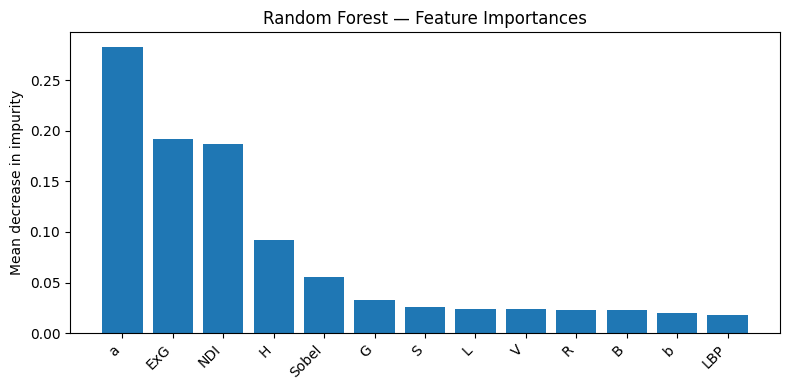

In [19]:
importances = rf.feature_importances_
order = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(FEATURE_NAMES)), importances[order])
ax.set_xticks(range(len(FEATURE_NAMES)))
ax.set_xticklabels([FEATURE_NAMES[i] for i in order], rotation=45, ha="right")
ax.set_ylabel("Mean decrease in impurity")
ax.set_title("Random Forest — Feature Importances")
plt.tight_layout()
plt.savefig("rf_feature_importance.png", dpi=150)
plt.show()

In [20]:
def predict_mask(model, img_rgb: np.ndarray) -> np.ndarray:
    """Extract features from a full image and return a (H, W) predicted mask."""
    H, W = img_rgb.shape[:2]
    X = extract_features(img_rgb)           # (H*W, 13)
    y_pred = model.predict(X)               # (H*W,)
    return predictions_to_mask(y_pred, H, W)


print("Running inference on validation set...")
t0 = time.time()

val_gt_masks   = []
val_pred_masks = []

for img_path, mask_path in zip(val_imgs, val_masks):
    img_rgb, gt_mask = load_image_mask_pair(img_path, mask_path)
    pred_mask = predict_mask(rf, img_rgb)
    val_gt_masks.append(gt_mask)
    val_pred_masks.append(pred_mask)

val_inference_time = time.time() - t0
print(f"Validation inference time: {val_inference_time:.2f}s ({val_inference_time/len(val_imgs):.2f}s/image)")

val_metrics_raw     = evaluate_dataset(val_gt_masks, val_pred_masks, apply_cleanup=False)
val_metrics_cleaned = evaluate_dataset(val_gt_masks, val_pred_masks, apply_cleanup=True)

print_metrics(val_metrics_raw,     "RF — Validation (raw)")
print_metrics(val_metrics_cleaned, "RF — Validation (after morphological cleanup)")

Running inference on validation set...
Validation inference time: 22.76s (0.95s/image)

  RF — Validation (raw)
  Precision    0.9370
  Recall       0.8405
  F1           0.8796
  Iou          0.7944


  RF — Validation (after morphological cleanup)
  Precision    0.9227
  Recall       0.9001
  F1           0.9050
  Iou          0.8364



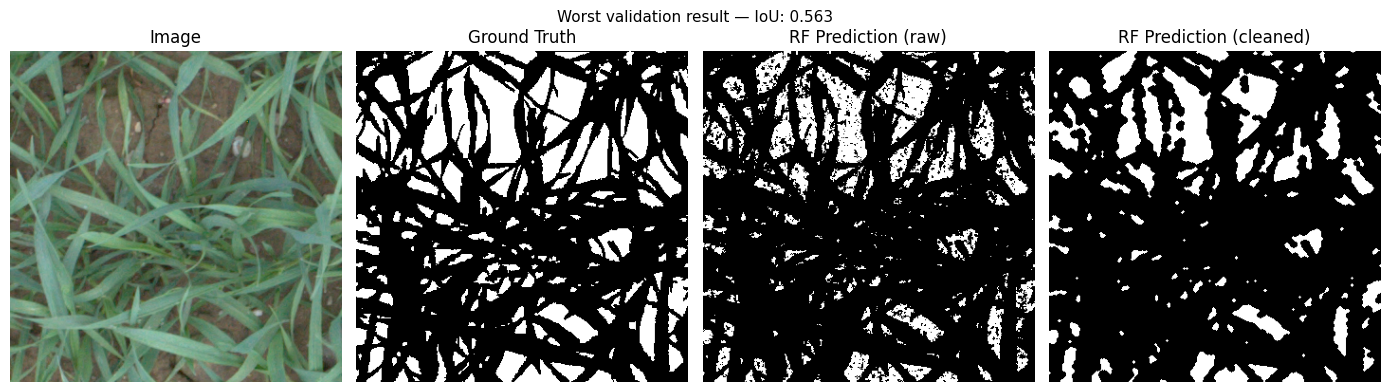

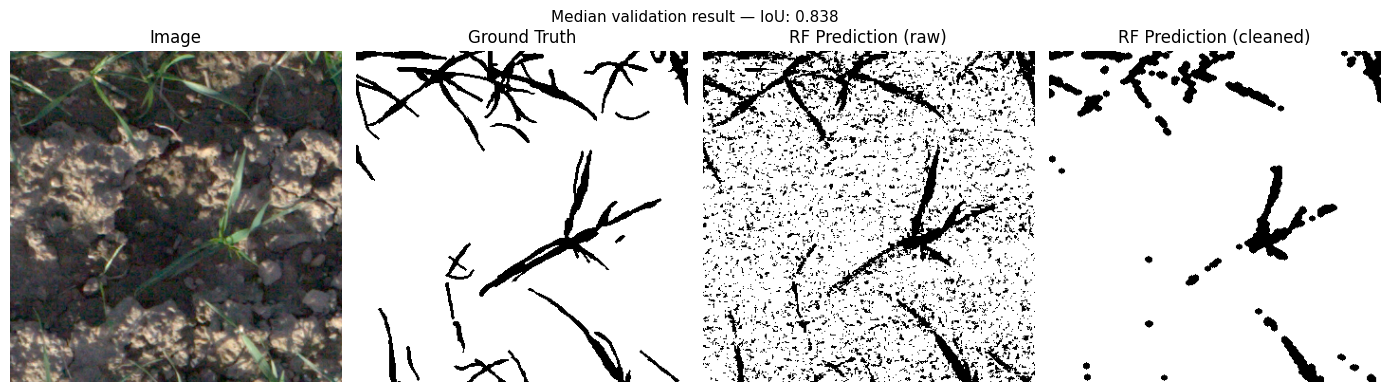

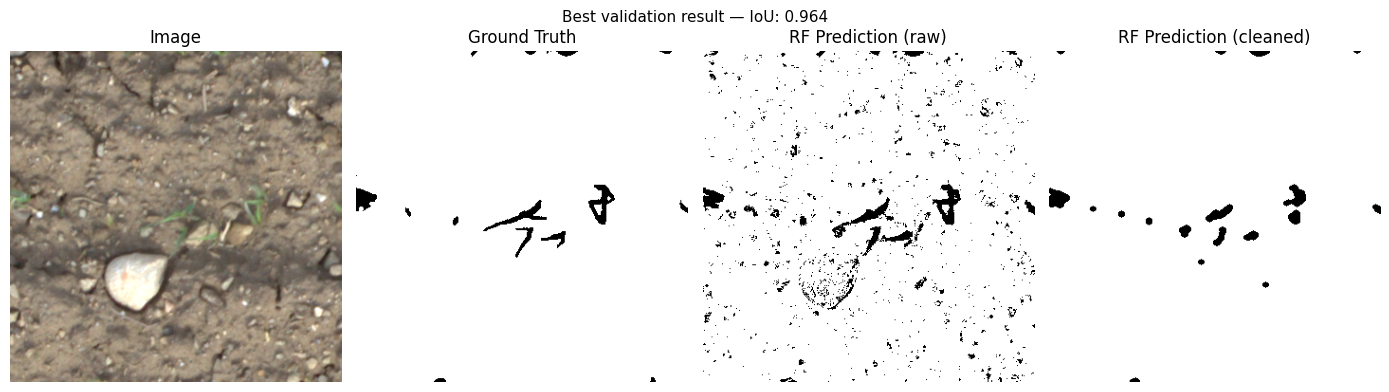

In [21]:
def visualise_predictions(img_rgb, gt_mask, pred_mask, title=""):
    """Plot image | ground truth | raw prediction | cleaned prediction side by side."""
    cleaned = morphological_cleanup(pred_mask)
    fig, axes = plt.subplots(1, 4, figsize=(14, 4))
    axes[0].imshow(img_rgb)
    axes[0].set_title("Image")
    axes[1].imshow(gt_mask,   cmap="gray")
    axes[1].set_title("Ground Truth")
    axes[2].imshow(pred_mask, cmap="gray")
    axes[2].set_title("RF Prediction (raw)")
    axes[3].imshow(cleaned,   cmap="gray")
    axes[3].set_title("RF Prediction (cleaned)")
    for ax in axes:
        ax.axis("off")
    if title:
        fig.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()


# Show best, median, and worst validation examples by IoU
val_ious = [m["iou"] for m in val_metrics_raw["per_image"]]
order    = np.argsort(val_ious)

for label, idx in [("Worst", order[0]), ("Median", order[len(order)//2]), ("Best", order[-1])]:
    img_rgb, gt_mask = load_image_mask_pair(val_imgs[idx], val_masks[idx])
    visualise_predictions(
        img_rgb, gt_mask, val_pred_masks[idx],
        title=f"{label} validation result — IoU: {val_ious[idx]:.3f}"
    )

In [22]:
print("Running inference on test set...")
t0 = time.time()

test_gt_masks   = []
test_pred_masks = []

for img_path, mask_path in zip(test_imgs, test_masks):
    img_rgb, gt_mask = load_image_mask_pair(img_path, mask_path)
    pred_mask = predict_mask(rf, img_rgb)
    test_gt_masks.append(gt_mask)
    test_pred_masks.append(pred_mask)
    # Save predicted masks for submission / further analysis
    save_mask(pred_mask, str(PRED_OUTPUT_DIR / img_path.name))

test_inference_time = time.time() - t0
print(f"Test inference time: {test_inference_time:.2f}s ({test_inference_time/len(test_imgs):.2f}s/image)")

test_metrics_raw     = evaluate_dataset(test_gt_masks, test_pred_masks, apply_cleanup=False)
test_metrics_cleaned = evaluate_dataset(test_gt_masks, test_pred_masks, apply_cleanup=True)

print_metrics(test_metrics_raw,     "RF — Test (raw)")
print_metrics(test_metrics_cleaned, "RF — Test (after morphological cleanup)")

print(f"\nTrain time:          {train_time:.2f}s")
print(f"Test inference time: {test_inference_time:.2f}s")

Running inference on test set...
Test inference time: 24.85s (1.04s/image)

  RF — Test (raw)
  Precision    0.9308
  Recall       0.8467
  F1           0.8803
  Iou          0.7920


  RF — Test (after morphological cleanup)
  Precision    0.9187
  Recall       0.9103
  F1           0.9095
  Iou          0.8396


Train time:          115.52s
Test inference time: 24.85s
